# Lab 01 Tasks
### Introductory Computer Vision Lab

### 1.2 Import & Validate

OpenCV version: 4.13.0
Matplotlib version: 3.10.8
NumPy version: 2.4.4
Pandas version: 3.0.2


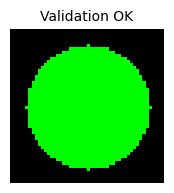

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("OpenCV version:", cv2.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

# Quick validation: draw a tiny test image and confirm plotting works
test_img = np.zeros((50, 50, 3), dtype=np.uint8)
cv2.circle(test_img, (25, 25), 20, (0, 255, 0), -1)
plt.figure(figsize=(2, 2))
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Validation OK', fontsize=10)
plt.show()


### Setup: Generate Sample Images
No source images were provided with this lab, so this helper cell synthetically generates a few sample images (including one named `Sukuna.jpeg`, as referenced by the task instructions) so every task below can run end-to-end. Replace these paths with your own images if you have them.

In [2]:
# No filler images needed anymore -- all images used in this lab are real photos
# (Sukuna.png, Gojo.png, Toji.png), already provided in the images/ folder.
print("Using real images: Sukuna.png, Gojo.png, Toji.png")

Using real images: Sukuna.png, Gojo.png, Toji.png


## Part 2: Python Data Structures & Logic

### Task 1: Object-Oriented Grocery Manager

In [3]:
class GroceryManager:
    def __init__(self):
        self.items = {}  # item -> {'quantity': int, 'price': float}

    def add_item(self, item, quantity, price):
        if item in self.items:
            self.items[item]['quantity'] += quantity
        else:
            self.items[item] = {'quantity': quantity, 'price': price}
        print(f"Added: {item} (qty={quantity}, price={price})")

    def remove_item(self, item):
        if item not in self.items:
            print(f"Error: '{item}' does not exist in the grocery list.")
            return
        del self.items[item]
        print(f"Removed: {item}")

    def view_list(self):
        if not self.items:
            print("Grocery list is empty.")
            return
        print(f"{'Item':<15}{'Quantity':<10}{'Price':<10}")
        for item, details in self.items.items():
            print(f"{item:<15}{details['quantity']:<10}{details['price']:<10}")

    def calculate_total(self):
        total = sum(d['quantity'] * d['price'] for d in self.items.values())
        return total


# --- Demo ---
gm = GroceryManager()
gm.add_item('Apples', 6, 0.5)
gm.add_item('Milk', 2, 3.2)
gm.add_item('Bread', 1, 2.75)
gm.view_list()
print("Total cost: $%.2f" % gm.calculate_total())

gm.remove_item('Milk')
gm.remove_item('Eggs')  # triggers error handling, doesn't exist
gm.view_list()


Added: Apples (qty=6, price=0.5)
Added: Milk (qty=2, price=3.2)
Added: Bread (qty=1, price=2.75)
Item           Quantity  Price     
Apples         6         0.5       
Milk           2         3.2       
Bread          1         2.75      
Total cost: $12.15
Removed: Milk
Error: 'Eggs' does not exist in the grocery list.
Item           Quantity  Price     
Apples         6         0.5       
Bread          1         2.75      


### Task 2: Advanced Student Record System

In [4]:
students = {
    'S001': {'Name': 'Ayesha', 'Major': 'Computer Science', 'Grades': [88, 92, 79]},
    'S002': {'Name': 'Bilal', 'Major': 'Electrical Engineering', 'Grades': [70, 65, 80]},
    'S003': {'Name': 'Sara', 'Major': 'Computer Science', 'Grades': [95, 91, 98]},
    'S004': {'Name': 'Hamza', 'Major': 'Mathematics', 'Grades': [60, 72, 68]},
    'S005': {'Name': 'Zara', 'Major': 'Electrical Engineering', 'Grades': [85, 82, 90]},
}


def student_with_highest_average(records):
    best_name = None
    best_avg = -1
    for info in records.values():
        avg = sum(info['Grades']) / len(info['Grades'])
        if avg > best_avg:
            best_avg = avg
            best_name = info['Name']
    return best_name, best_avg


def students_in_major(records, major):
    matches = [info['Name'] for info in records.values() if info['Major'].lower() == major.lower()]
    if matches:
        print(f"Students enrolled in {major}:")
        for name in matches:
            print(f" - {name}")
    else:
        print(f"No students found for major: {major}")
    return matches


# --- Demo ---
top_name, top_avg = student_with_highest_average(students)
print(f"Top student: {top_name} (avg={top_avg:.2f})")
print()
students_in_major(students, 'Computer Science')


Top student: Sara (avg=94.67)

Students enrolled in Computer Science:
 - Ayesha
 - Sara


['Ayesha', 'Sara']

## Part 3: Core Computer Vision & Matplotlib
*All image visualization tasks utilize Matplotlib subplots for side-by-side comparisons unless stated otherwise.*

### Task 3: Safe Image Loading & RGB Visualization (10 Mins)

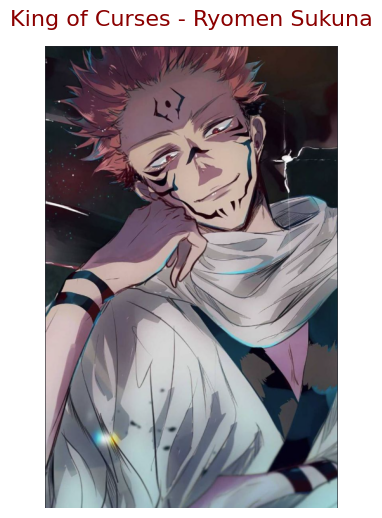

In [5]:
image_path = 'images/Sukuna.png'
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.axis('off')
    plt.imshow(image_rgb)
    plt.title('King of Curses - Ryomen Sukuna', fontsize=16, color='darkred', pad=15)
    plt.show()


### Task 4: Interactive Geometry & Blank Canvas

Canvas center coordinates: (400, 400)


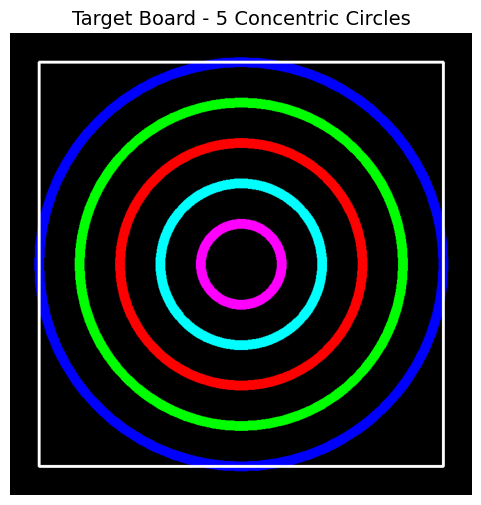

In [6]:
canvas = np.zeros((800, 800, 3), dtype=np.uint8)

center = (400, 400)
radii = [350, 280, 210, 140, 70]
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]  # alternating colors (BGR)

for radius, color in zip(radii, colors):
    cv2.circle(canvas, center, radius, color, thickness=15)

max_radius = max(radii)
top_left = (center[0] - max_radius, center[1] - max_radius)
bottom_right = (center[0] + max_radius, center[1] + max_radius)
cv2.rectangle(canvas, top_left, bottom_right, (255, 255, 255), thickness=3)

print(f"Canvas center coordinates: {center}")

canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(canvas_rgb)
plt.title('Target Board - 5 Concentric Circles', fontsize=14)
plt.show()


### Task 5: Advanced Blurring & NumPy ROI Extraction

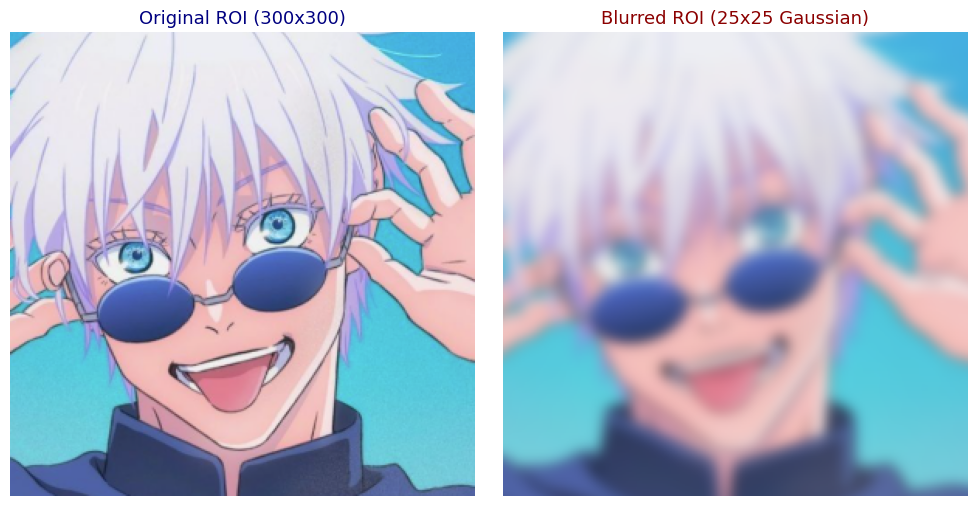

In [7]:
image_path = 'images/Gojo.png'
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    blurred_rgb = cv2.GaussianBlur(image_rgb, (25, 25), 0)

    h, w, _ = image_rgb.shape
    cy, cx = h // 2, w // 2
    half = 150  # 300x300 ROI

    roi_original = image_rgb[cy - half:cy + half, cx - half:cx + half]
    roi_blurred = blurred_rgb[cy - half:cy + half, cx - half:cx + half]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(roi_original)
    axes[0].axis('off')
    axes[0].set_title('Original ROI (300x300)', fontsize=13, color='navy')

    axes[1].imshow(roi_blurred)
    axes[1].axis('off')
    axes[1].set_title('Blurred ROI (25x25 Gaussian)', fontsize=13, color='darkred')

    plt.tight_layout()
    plt.show()


### Task 6: Alpha Blending & Typography

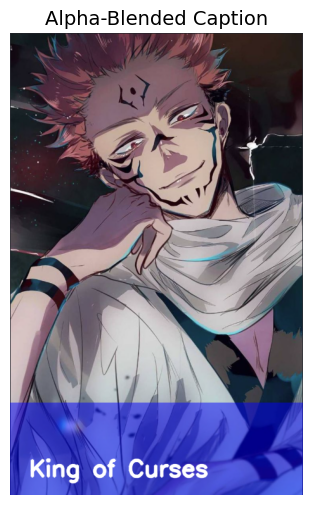

In [8]:
image_path = 'images/Sukuna.png'
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    h, w, _ = image.shape
    overlay = image.copy()

    overlay_height = int(h * 0.20)
    cv2.rectangle(overlay, (0, h - overlay_height), (w, h), (255, 0, 0), -1)  # blue rectangle (BGR)

    blended = cv2.addWeighted(overlay, 0.5, image, 0.5, 0)

    cv2.putText(blended, 'King of Curses', (30, h - 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3, cv2.LINE_AA)

    blended_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.axis('off')
    plt.imshow(blended_rgb)
    plt.title('Alpha-Blended Caption', fontsize=14)
    plt.show()


### Task 7: Matrix-Based Rotation & Adaptive Thresholding

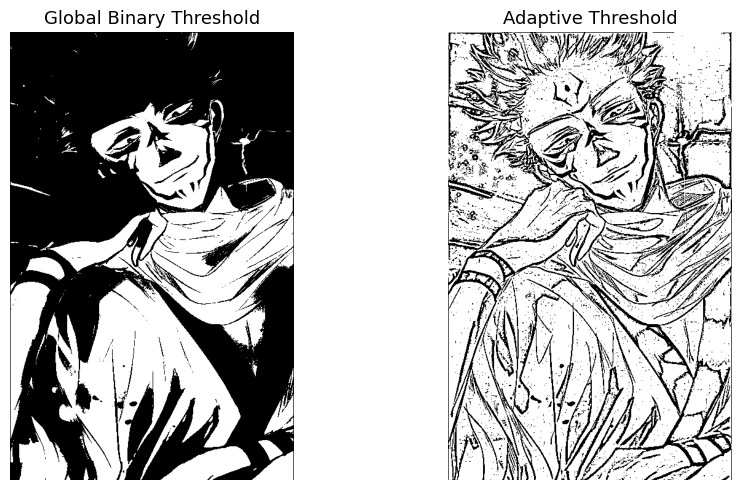

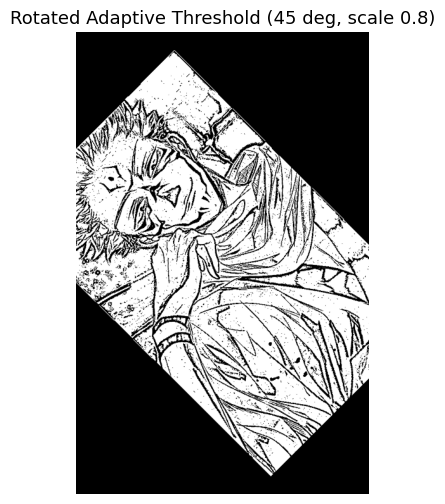

In [9]:
image_path = 'images/Sukuna.png'
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    _, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    adaptive_thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(global_thresh, cmap='gray')
    axes[0].axis('off')
    axes[0].set_title('Global Binary Threshold', fontsize=13)

    axes[1].imshow(adaptive_thresh, cmap='gray')
    axes[1].axis('off')
    axes[1].set_title('Adaptive Threshold', fontsize=13)
    plt.tight_layout()
    plt.show()

    h, w = adaptive_thresh.shape
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, 45, 0.8)
    rotated = cv2.warpAffine(adaptive_thresh, rotation_matrix, (w, h))

    plt.figure(figsize=(6, 6))
    plt.axis('off')
    plt.imshow(rotated, cmap='gray')
    plt.title('Rotated Adaptive Threshold (45 deg, scale 0.8)', fontsize=13)
    plt.show()


### Task 8: Masking with Bitwise Logic

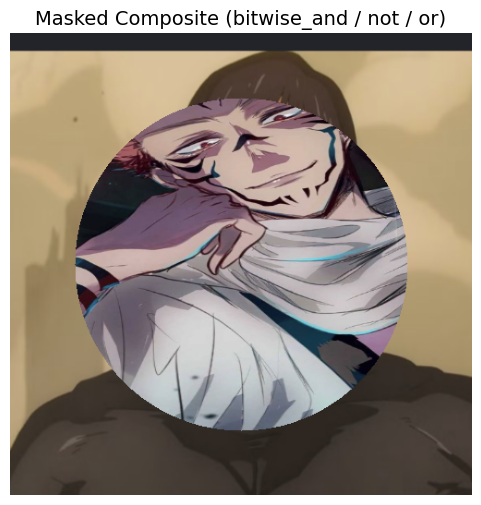

In [10]:
img1 = cv2.imread('images/Sukuna.png')
img2 = cv2.imread('images/Toji.png')

if img1 is None or img2 is None:
    print("Error: One or both images not found.")
else:
    size = (500, 500)
    img1 = cv2.resize(img1, size)
    img2 = cv2.resize(img2, size)

    mask = np.zeros(size[::-1], dtype=np.uint8)
    cv2.circle(mask, (250, 250), 180, 255, -1)  # white filled circle mask

    foreground = cv2.bitwise_and(img1, img1, mask=mask)

    inverse_mask = cv2.bitwise_not(mask)
    background = cv2.bitwise_and(img2, img2, mask=inverse_mask)

    combined = cv2.bitwise_or(foreground, background)

    combined_rgb = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.axis('off')
    plt.imshow(combined_rgb)
    plt.title('Masked Composite (bitwise_and / not / or)', fontsize=14)
    plt.show()


### Task 9: Statistical Image Profiling with Pandas

In [11]:
image_path = 'images/Sukuna.png'
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    red_channel = image_rgb[:, :, 0].flatten()
    green_channel = image_rgb[:, :, 1].flatten()
    blue_channel = image_rgb[:, :, 2].flatten()

    df = pd.DataFrame({'Red': red_channel, 'Green': green_channel, 'Blue': blue_channel})

    summary = df.describe()
    print(summary)


                 Red          Green           Blue
count  337260.000000  337260.000000  337260.000000
mean      112.968078     105.614137     112.601017
std        63.714244      64.299539      61.417980
min         0.000000       0.000000       0.000000
25%        54.000000      41.000000      54.000000
50%       115.000000     100.000000     113.000000
75%       169.000000     173.000000     171.000000
max       255.000000     254.000000     255.000000
